# Emotion Classification Baseline with dair-ai/emotion
This notebook performs initial data exploration and trains a simple baseline model.
Goal: Establish a minimal performance benchmark before building a more sophisticated pipeline.

In [36]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from datasets import load_dataset
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_style("whitegrid")

In [37]:
# Loading the emotion dataset
dataset = load_dataset("dair-ai/emotion", split='train')
df = dataset.to_pandas()
print(f"Dataset shape: {df.shape}")

'[SSL: UNEXPECTED_EOF_WHILE_READING] EOF occurred in violation of protocol (_ssl.c:1000)' thrown while requesting HEAD https://huggingface.co/datasets/dair-ai/emotion/resolve/cab853a1dbdf4c42c2b3ef2173804746df8825fe/emotion.py
Retrying in 1s [Retry 1/5].
Using the latest cached version of the dataset since dair-ai/emotion couldn't be found on the Hugging Face Hub
Found the latest cached dataset configuration 'split' at /home/khalifa/.cache/huggingface/datasets/dair-ai___emotion/split/0.0.0/cab853a1dbdf4c42c2b3ef2173804746df8825fe (last modified on Wed Jun 10 10:58:02 2026).


Dataset shape: (16000, 2)


In [38]:
df.head()

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,3


In [39]:
df['emotion'] = df['label'].apply(lambda x: label_names[x])
print(df[['text', 'emotion']].head())

                                                text  emotion
0                            i didnt feel humiliated  sadness
1  i can go from feeling so hopeless to so damned...  sadness
2   im grabbing a minute to post i feel greedy wrong    anger
3  i am ever feeling nostalgic about the fireplac...     love
4                               i am feeling grouchy    anger


In [40]:
df['emotion'].value_counts()

emotion
joy         5362
sadness     4666
anger       2159
fear        1937
love        1304
surprise     572
Name: count, dtype: int64

/tmp/ipykernel_5475/270225636.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')


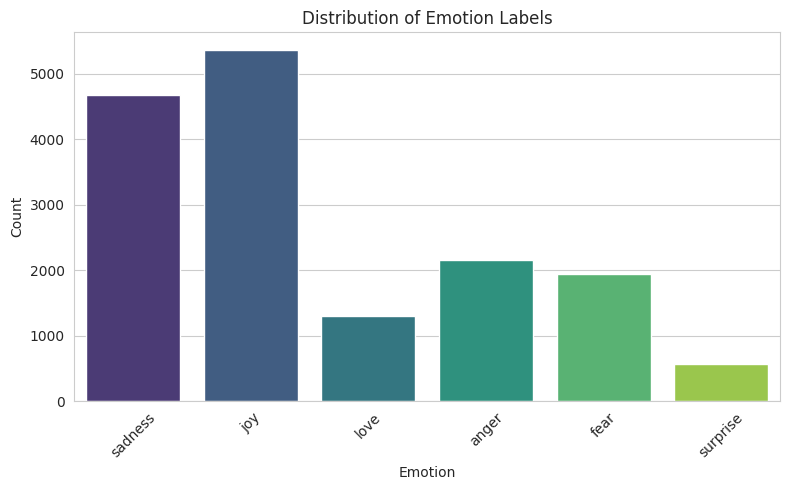

Label distribution:
sadness     4666
joy         5362
love        1304
anger       2159
fear        1937
surprise     572
Name: count, dtype: int64


In [41]:
# Label distribution
label_counts = df['label'].value_counts().sort_index()
label_names = dataset.features['label'].names
label_counts.index = [label_names[i] for i in label_counts.index]

plt.figure(figsize=(8, 5))
sns.barplot(x=label_counts.index, y=label_counts.values, palette='viridis')
plt.title("Distribution of Emotion Labels")
plt.xlabel("Emotion")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

print("Label distribution:")
print(label_counts)

In [42]:
from collections import Counter

def get_top_words(texts):
    words = " ".join(texts).split()
    return Counter(words).most_common(10)

for emotion in df['emotion'].unique():
    texts = df[df['emotion'] == emotion]['text']
    print(emotion, get_top_words(texts))

sadness [('i', 7635), ('feel', 3299), ('and', 2692), ('to', 2335), ('the', 2155), ('a', 1656), ('feeling', 1523), ('of', 1422), ('that', 1299), ('my', 1245)]
anger [('i', 3576), ('feel', 1459), ('and', 1258), ('to', 1162), ('the', 1109), ('a', 791), ('feeling', 721), ('that', 705), ('of', 630), ('my', 573)]
love [('i', 2120), ('feel', 929), ('and', 902), ('to', 860), ('the', 780), ('a', 571), ('of', 482), ('that', 460), ('my', 399), ('feeling', 378)]
surprise [('i', 927), ('feel', 356), ('and', 354), ('the', 335), ('to', 267), ('a', 256), ('that', 212), ('feeling', 209), ('of', 191), ('my', 163)]
fear [('i', 3083), ('feel', 1212), ('to', 1116), ('and', 1110), ('the', 1000), ('a', 806), ('feeling', 742), ('of', 614), ('that', 531), ('my', 525)]
joy [('i', 8518), ('feel', 3928), ('and', 3273), ('to', 3232), ('the', 2991), ('a', 2120), ('that', 1905), ('of', 1651), ('feeling', 1539), ('my', 1378)]


In [43]:
# Simple baseline: TF-IDF + Logistic Regression
X = df['text']
y = df['label']

# Train/test split (here we use the dataset's train split; later we'll use proper splits)
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=10000, ngram_range=(1,2))),
    ('clf', LogisticRegression(max_iter=1000, random_state=42))
])

pipeline.fit(X_train, y_train)
print("Training complete.")

Training complete.


Validation Accuracy: 0.8178

Classification Report:
              precision    recall  f1-score   support

     sadness       0.84      0.91      0.87       933
         joy       0.76      0.96      0.84      1072
        love       0.86      0.46      0.60       261
       anger       0.91      0.74      0.82       432
        fear       0.87      0.69      0.77       387
    surprise       0.93      0.33      0.49       115

    accuracy                           0.82      3200
   macro avg       0.86      0.68      0.73      3200
weighted avg       0.83      0.82      0.81      3200



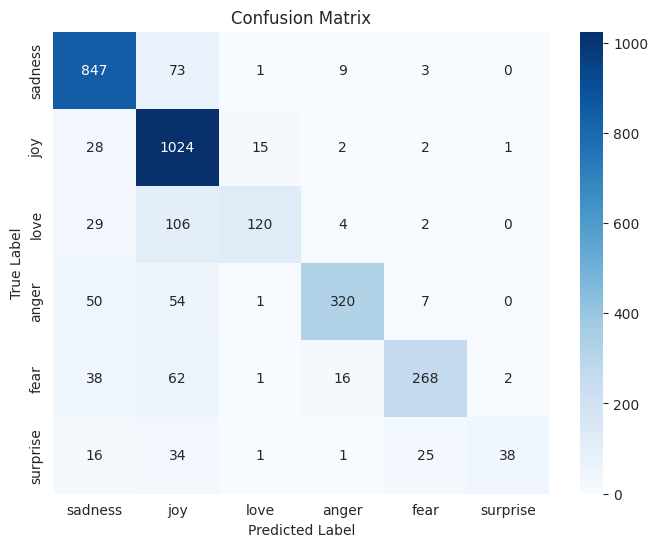

In [44]:
# Evaluation
y_pred = pipeline.predict(X_val)
acc = accuracy_score(y_val, y_pred)
print(f"Validation Accuracy: {acc:.4f}")

print("\nClassification Report:")
print(classification_report(y_val, y_pred, target_names=label_names))

cm = confusion_matrix(y_val, y_pred)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', xticklabels=label_names, yticklabels=label_names, cmap='Blues')
plt.title('Confusion Matrix')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

## Baseline Analysis & Key Findings

### Performance Summary
- **Overall Accuracy**: 81.8% — decent for a simple TF-IDF + Logistic Regression pipeline
- **Critical Issue**: Accuracy is misleading due to severe class imbalance

### Class Imbalance Impact

| Emotion   | Support | Recall | Problem |
|-----------|---------|--------|---------|
| sadness   | 933     | 0.91   | ✅ Strong |
| joy       | 1072    | 0.96   | ✅ Strong |
| love      | 261     | 0.46   | ❌ Missed 54% |
| anger     | 432     | 0.74   | ⚠️ Moderate |
| fear      | 387     | 0.69   | ⚠️ Moderate |
| surprise  | 115     | 0.33   | ❌ Missed 67% |

### Key Observations

1. **Majority class bias**: Joy (33.5%) and Sadness (29.2%) dominate training → model over-optimizes for them
2. **Love → Joy confusion**: 106 of 261 love samples classified as joy. Semantically related emotions are hard to separate with bag-of-words features
3. **Surprise collapse**: Only 38/115 correctly classified. Model effectively ignores this class
4. **Macro-F1 (0.73) vs Accuracy (0.82) gap**: Confirms imbalance is masking poor minority-class performance

### Design Implications

**These findings justify architectural decisions moving forward:**

- ❌ **TF-IDF is insufficient**: Bag-of-words cannot capture semantic similarity between "love" and "joy" expressions
- ✅ **Need contextual embeddings**: Transformer models (DistilBERT, RoBERTa) can disambiguate fine-grained emotions
- ✅ **Class weighting required**: Must address imbalance with weighted loss or oversampling
- ✅ **Metric choice matters**: Macro-F1 or balanced accuracy is a better optimization target than raw accuracy
- ✅ **Evaluation must stratify**: Always use stratified splits to preserve class proportions

### Next Phase Goals

We need:
1. Contextual embeddings (transformer-based)
2. Class-weighted training or data augmentation for minority classes
3. Evaluation focused on per-class F1, not overall accuracy
4. Proper train/val/test split using the official dataset splits